In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal 
import numpy as np
import os
import glob

# Data import

In [2]:
# Working path
folder = 'Rawdata' # Esto lo pueden cambiar, pero les recomiendo simplemente usar el mismo nombre
cwd = os.getcwd()
folderpath = os.path.join(cwd,folder)
print(folderpath)


c:\Users\josee\OneDrive\Documentos\GitHub\NeuroHAD2025\FILAnalysis\Rawdata


In [3]:
# Aquí enlistan las sesiones que les toca analizar
sessions = [39, 41, 42, 43, 44, 45, 48]


# Se guardan los datos de las sesiones en un diccionario
data = {skey: {} for skey in sessions}
for sn in sessions:
    pattern = f"S{sn}R*"
    snpath = glob.glob(os.path.join(folderpath, pattern))[0]

    p1 = (
        pd.read_csv(os.path.join(snpath, "Raw.csv"))
        .replace(["TP9", "TP10", "AF7", "AF8", "board_ts", "unix_ts"], np.nan)
        .dropna()
        .drop("Unnamed: 0", axis=1)
        .astype(float)
    )
    p2 = (
        pd.read_csv(os.path.join(snpath, "Raw2.csv"))
        .replace(["TP9", "TP10", "AF7", "AF8", "board_ts", "unix_ts"], np.nan)
        .dropna()
        .drop("Unnamed: 0", axis=1)
        .astype(float)
    )
    mks = pd.read_csv(os.path.join(snpath, "markers.csv"))

    data[sn].update({'p1':p1, 'p2':p2, 'mks':mks})


In [4]:
data[39]['mks']

,unix_ts,key,label
0,1.760827e+09,1,baseline_start
1,1.760828e+09,2,shared_start
2,1.760828e+09,3,individual_start


# Filtering and data segmentation

In [5]:
# Filter creation
fs = 256
sos = signal.butter(2, [4, 50], 'bandpass', fs=fs, output='sos') # Butterworth digital bandpass filter from 4-50Hz

In [6]:
def extract_segments(df, mks, fs):
    def get_segment_for_key(key, pre_offset_s, duration_s):
        # Timestamp del marcador correspondiente (usamos unix_ts de mks)
        t0 = mks.loc[mks['key'] == key, 'unix_ts'].iloc[0]

        # Índice del primer dato en df cuyo unix_ts >= t0
        idx0 = df.index[df['unix_ts'] >= t0][0]

        # Convertir segundos a muestras
        offset_samples = int(pre_offset_s * fs)
        duration_samples = int(duration_s * fs)

        start = idx0 + offset_samples
        end = start + duration_samples

        # Seguridad por si el segmento se sale del tamaño del df
        end = min(end, len(df))

        # Devolvemos un df con las mismas columnas, sólo cortado
        return df.iloc[start:end].reset_index(drop=True)

    segments = {
        'baseline':   get_segment_for_key(key=1, pre_offset_s=10, duration_s=110),
        'shared':     get_segment_for_key(key=2, pre_offset_s=15, duration_s=270),
        'individual': get_segment_for_key(key=3, pre_offset_s=15, duration_s=270),
    }

    return segments


eeg_cols = ['TP9', 'TP10', 'AF7', 'AF8']
for sn in sessions:
# Filtrado y segmentación para cada participante
    for subj in ['p1', 'p2']:
        df = data[sn][subj]

        df_filt = df.copy()

        # Aplicar filtro sólo a los canales EEG
        df_filt[eeg_cols] = signal.sosfiltfilt(sos, df[eeg_cols].values, axis=0)

        # Guardar datos filtrados
        data[sn][f'{subj}_filt'] = df_filt

        # Segmentar usando los datos filtrados y los markers de la sesión
        segments = extract_segments(df_filt, data[sn]['mks'], fs)
        # Quedaría algo como rawdata[sn]['p1_segments']['baseline'], etc.
        data[sn][f'{subj}_segments'] = segments

In [7]:

data[39]['p1_segments']['shared']

,TP9,AF7,AF8,TP10,board_ts,unix_ts
0,-154.132245,-11.669437,2.766794,-8.977577,1.760828e+09,1.760828e+09
1,-148.051150,-7.434663,0.095333,-2.849682,1.760828e+09,1.760828e+09
2,-2.342983,-3.342389,-0.958508,-0.213122,1.760828e+09,1.760828e+09
3,66.993016,-0.801865,-1.639481,-3.657266,1.760828e+09,1.760828e+09
4,-7.940191,-0.387102,-2.638089,-12.079387,1.760828e+09,1.760828e+09
...,...,...,...,...,...,...
69115,115.591233,0.107612,5.503229,14.143642,1.760828e+09,1.760828e+09
69116,285.023358,8.871372,7.954368,28.285864,1.760828e+09,1.760828e+09
69117,311.009360,15.465882,6.160217,40.307467,1.760828e+09,1.760828e+09
69118,255.173358,18.490177,2.438463,42.792313,1.760828e+09,1.760828e+09


(0.0, 20000.0)

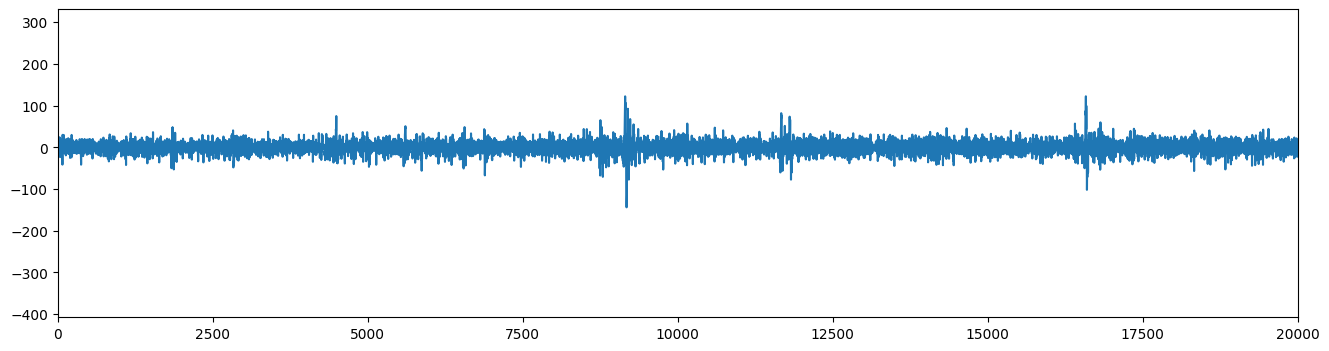

In [92]:
plt.figure(figsize=(16, 4))
plt.plot(data[41]['p1_segments']['shared']['AF8'])
plt.xlim([0,20000])
# plt.ylim([-100,100])